In [ ]:
!pip install ultralytics roboflow opencv-python matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.9/175.9 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 71.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 100.7 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf=Roboflow(api_key="LeqPf9aYwWdLNy3CcI2H")
project=rf.workspace("jussyan").project("vehicles-22g3b-qki3p")
version=project.version(1)
dataset=version.download("yolov11")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Vehicles-1 in yolov11:: 100%|██████████| 4439/4439 [00:00<00:00, 8516.64it/s]


In [ ]:
from ultralytics import YOLO

model=YOLO('/content/yolo11s.pt')

results=model.train(
    data=r"/content/Vehicles-1/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    name="custom_yolov11n_train",
    patience=10
)

Ultralytics 8.4.41 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Vehicles-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=custom_yolov11n_train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap

In [ ]:
metrics=model.val()

print(f"mAP@50: {metrics.box.map50:.3f}")
print(f"mAP@50:95: {metrics.box.map:.3f}")
print(f"Precision: {metrics.box.p.mean():.3f}")
print(f"Recall: {metrics.box.r.mean():.3f}")

Ultralytics 8.4.41 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,414,735 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1093.2±253.7 MB/s, size: 33.1 KB)
val: Scanning /content/Vehicles-1/valid/labels.cache... 74 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 74/74 18.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.2it/s 4.2s
                   all         74        670      0.906      0.684      0.779      0.528
               bicycle          7          8       0.82       0.75      0.719      0.483
                   bus         15         22          1      0.588      0.749      0.515
                   car         68        386      0.932       0.75      0.871      0.632
             motorbike         52        201      0.896      0.728      0.839        0.5
                 truck         36         53    


0: 640x640 1 car, 5 motorbikes, 27.0ms
1: 640x640 1 car, 2 motorbikes, 27.0ms
2: 640x640 8 cars, 27.0ms
Speed: 7.4ms preprocess, 27.0ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict
3 labels saved to /content/runs/detect/predict/labels


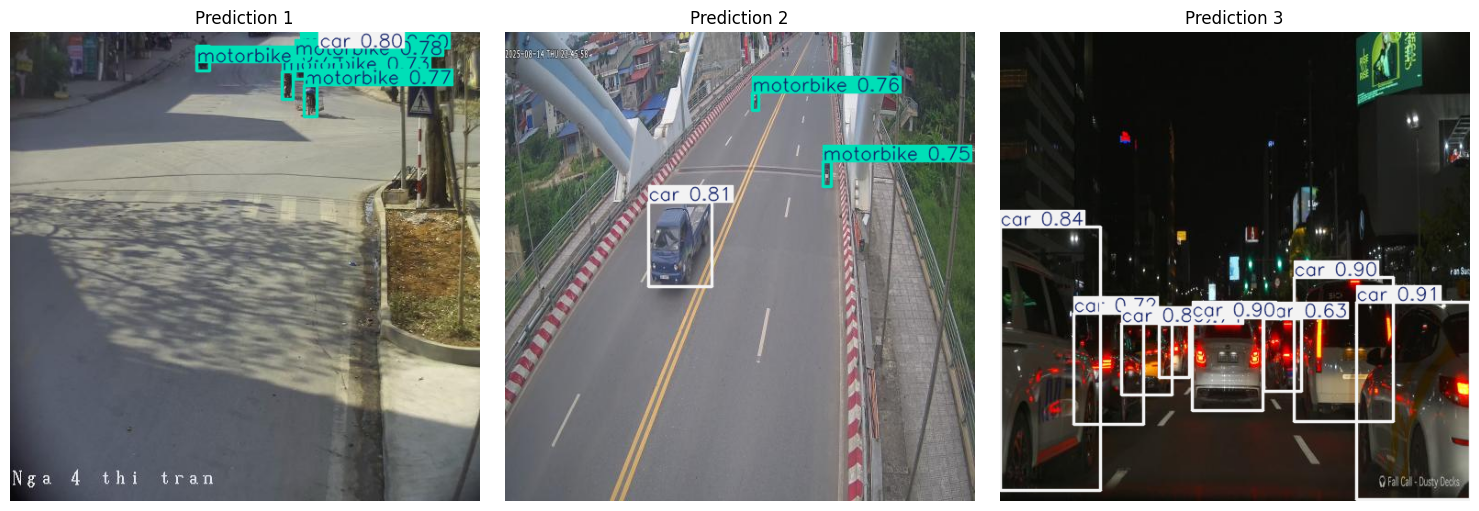

In [ ]:
import matplotlib.pyplot as plt
import cv2

image_path=["/content/Vehicles-1/test/images/57384_jpg.rf.dbf0ebcfcad62772aee98e877f4fcb11.jpg",
            "/content/Vehicles-1/test/images/_root_tungn197_license-plate-recognition_data_recordings_cam05_cam05_20250814-145534_t000050s_jpg.rf.dd20b47fd013685eb5adaf68edc68ffc.jpg",
            "/content/Vehicles-1/test/images/youtube-48_jpg.rf.bcb5642d62b372268011b381010d176a.jpg"]

results=model.predict(
    source=image_path,
    save=True,
    save_txt=True,
    conf=0.6,
    iou=0.45
)

#Subplot
plt.figure(figsize=(15, 5))
for i, result in enumerate(results):
  plt.subplot(1, 3, i+1)
  plt.imshow(cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB))
  plt.title(f"Prediction {i+1}")
  plt.axis('off')

plt.tight_layout()
plt.show()